In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
import os
os.chdir("../output/supervised/")

In [2]:
hancock_16 = pd.read_csv("HANCOCK_regression_results_16.csv")
hancock_16["dim"] = 16
hancock_32 = pd.read_csv("HANCOCK_regression_results_32.csv")
hancock_32["dim"] = 32
hancock_64 = pd.read_csv("HANCOCK_regression_results_64.csv")
hancock_64["dim"] = 64
hancock_comb = pd.concat([hancock_16, hancock_32, hancock_64], ignore_index=True)
hancock_comb = hancock_comb[hancock_comb["Method"] != "Random"]
hancock_comb["Mode"] = "Combined"

hancock_num_16 = pd.read_csv("HANCOCK_numeric_only_regression_results_16.csv")
hancock_num_16["dim"] = 16
hancock_num_32 = pd.read_csv("HANCOCK_numeric_only_regression_results_32.csv")
hancock_num_32["dim"] = 32
hancock_num_64 = pd.read_csv("HANCOCK_numeric_only_regression_results_64.csv")
hancock_num_64["dim"] = 64
hancock_num_comb = pd.concat([hancock_num_16, hancock_num_32, hancock_num_64], ignore_index=True)
hancock_num_comb = hancock_num_comb[hancock_num_comb["Method"] != "Random"]
hancock_num_comb["Mode"] = "Numeric only"

hancock_cat_16 = pd.read_csv("HANCOCK_cat_only_regression_results_16.csv")
hancock_cat_16["dim"] = 16
hancock_cat_32 = pd.read_csv("HANCOCK_cat_only_regression_results_32.csv")
hancock_cat_32["dim"] = 32
hancock_cat_64 = pd.read_csv("HANCOCK_cat_only_regression_results_64.csv")
hancock_cat_64["dim"] = 64
hancock_cat_comb = pd.concat([hancock_cat_16, hancock_cat_32, hancock_cat_64], ignore_index=True)
hancock_cat_comb = hancock_cat_comb[hancock_cat_comb["Method"] != "Random"]
hancock_cat_comb["Mode"] = "Categorical only"

hancock_all = pd.concat([hancock_comb, hancock_num_comb, hancock_cat_comb], ignore_index=True)
# 4 targets: {'Days to RFS', 'RFS Event', 'Recurrence', 'Survival'}

tcga_16 = pd.read_csv("TCGA_LUAD_regression_results_16.csv")
tcga_16["dim"] = 16
tcga_32 = pd.read_csv("TCGA_LUAD_regression_results_32.csv")
tcga_32["dim"] = 32
tcga_64 = pd.read_csv("TCGA_LUAD_regression_results_64.csv")
tcga_64["dim"] = 64
tcga_comb = pd.concat([tcga_16, tcga_32, tcga_64], ignore_index=True)
tcga_comb = tcga_comb[tcga_comb["Method"] != "Random"]
tcga_comb["Mode"] = "Combined"

tcga_num_16 = pd.read_csv("TCGA_LUAD_numeric_only_regression_results_16.csv")
tcga_num_16["dim"] = 16
tcga_num_32 = pd.read_csv("TCGA_LUAD_numeric_only_regression_results_32.csv")
tcga_num_32["dim"] = 32
tcga_num_64 = pd.read_csv("TCGA_LUAD_numeric_only_regression_results_64.csv")
tcga_num_64["dim"] = 64
tcga_num_comb = pd.concat([tcga_num_16, tcga_num_32, tcga_num_64], ignore_index=True)
tcga_num_comb = tcga_num_comb[tcga_num_comb["Method"] != "Random"]
tcga_num_comb["Mode"] = "Numeric only"

tcga_cat_16 = pd.read_csv("TCGA_LUAD_cat_only_regression_results_16.csv")
tcga_cat_16["dim"] = 16
tcga_cat_32 = pd.read_csv("TCGA_LUAD_cat_only_regression_results_32.csv")
tcga_cat_32["dim"] = 32
tcga_cat_64 = pd.read_csv("TCGA_LUAD_cat_only_regression_results_64.csv")
tcga_cat_64["dim"] = 64
tcga_cat_comb = pd.concat([tcga_cat_16, tcga_cat_32, tcga_cat_64], ignore_index=True)
tcga_cat_comb = tcga_cat_comb[tcga_cat_comb["Method"] != "Random"]
tcga_cat_comb["Mode"] = "Categorical only"
tcga_all = pd.concat([tcga_comb, tcga_num_comb, tcga_cat_comb], ignore_index=True)
# 6 targets : {'Disease Free (Months)',
#'Disease Free Status',
#'Disease-specific Survival status',
#'Months of disease-specific survival',
#'Progress Free Survival (Months)',
#'Progression Free Status'}

In [ ]:
DIMENSION = 64


In [13]:
df = hancock_all[(hancock_all["dim"] == DIMENSION) & (hancock_all["Target"].isin(["Recurrence", "Survival", "RFS Event"]))]

median_scores = (
    df.groupby(['Method', 'Target', 'Mode'])['Score']
      .median()
      .unstack('Mode')
)

median_scores['Combined_best'] = (
    (median_scores['Combined'] > median_scores['Categorical only']) &
    (median_scores['Combined'] > median_scores['Numeric only'])
)

method_summary = (
    median_scores.groupby(level='Method')['Combined_best']
    .agg(
        count_higher='sum',
        total_targets='count',
        proportion=lambda x: x.mean()
    )
    .reset_index()
)

hancock_summary_df = method_summary[method_summary['Method'].isin(['POME', 'UMAP'])]
print(hancock_summary_df)

  Method  count_higher  total_targets  proportion
1   POME             1              3    0.333333
2   UMAP             0              3    0.000000


In [17]:
df = tcga_all[(tcga_all["dim"] == DIMENSION) & (tcga_all["Target"].isin(["Disease Free Status", "Disease-specific Survival status", "Progression Free Status"]))]
median_scores = (
    df.groupby(['Method', 'Target', 'Mode'])['Score']
      .median()
      .unstack('Mode')
)

median_scores['Combined_best'] = (
    (median_scores['Combined'] > median_scores['Categorical only']) &
    (median_scores['Combined'] > median_scores['Numeric only'])
)

method_summary = (
    median_scores.groupby(level='Method')['Combined_best']
    .agg(
        count_higher='sum',
        total_targets='count',
        proportion=lambda x: x.mean()
    )
    .reset_index()
)

tcga_summary_df = method_summary[method_summary['Method'].isin(['POME', 'UMAP'])]
print(tcga_summary_df)

  Method  count_higher  total_targets  proportion
1   POME             3              3         1.0
2   UMAP             0              3         0.0


/tmp/ipykernel_58221/453622391.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hancock_summary_df, x='Method', y='count_higher', ax=axes['a'],
/tmp/ipykernel_58221/453622391.py:15: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(data=hancock_summary_df, x='Method', y='count_higher', ax=axes['a'],
/tmp/ipykernel_58221/453622391.py:32: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(data=rec_all, x="Method", y="Score",
/tmp/ipykernel_58221/453622391.py:70: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.boxplot(data=surv_all, x="Method", y="Score",
/tmp/ipykernel_58221/453622391.py:96: UserWarning: The palette list has more values (10) than needed (3), which 

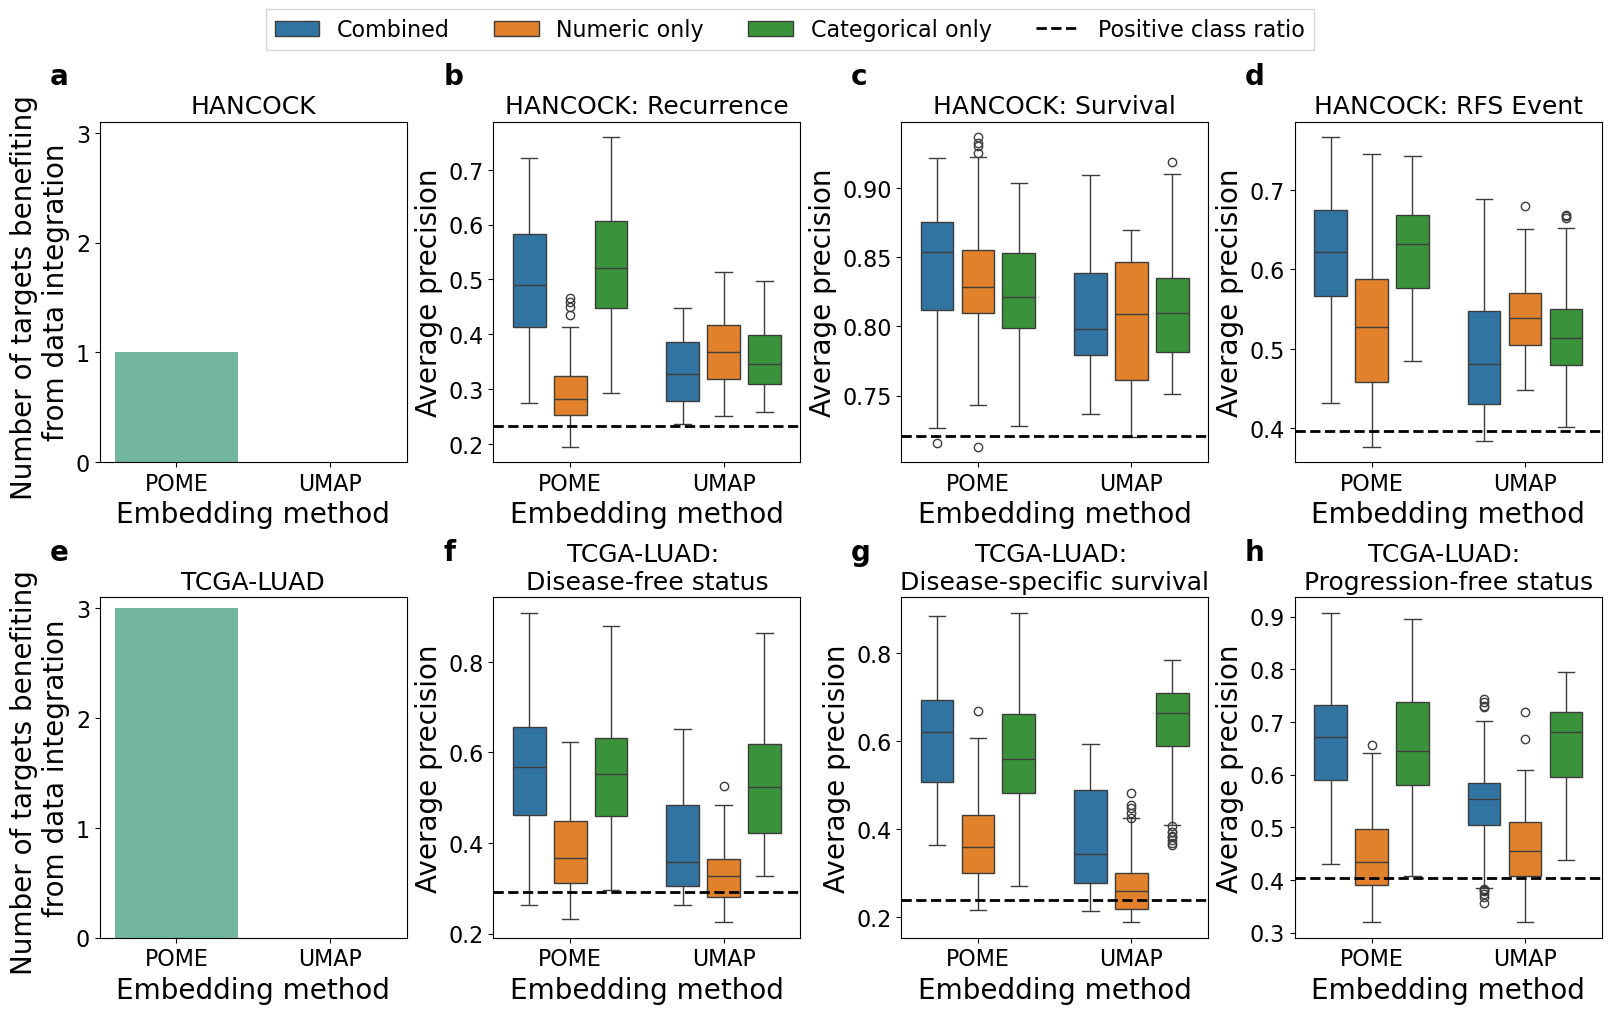

In [45]:
mosaic = [
['a', 'b', 'c', 'd'], ['e', 'f', 'g', 'h']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16,9.5), layout='constrained')

offset = transforms.ScaledTranslation(-36/72, 27/72, fig.dpi_scale_trans)
labelfontsize = 20
titlefontsize = 18
ticklabelsize = 16
xylabelsize = 18
legendfontsize = 16
legendtitlefontsize = 18
pvalfontsize = 18

sns.barplot(data=hancock_summary_df, x='Method', y='count_higher', ax=axes['a'],
            palette=sns.color_palette("Set2"))

axes['a'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['a'].set_ylabel('Number of targets benefiting \nfrom data integration', fontsize=labelfontsize) 
axes['a'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['a'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['a'].set_title("HANCOCK", fontsize=titlefontsize)
axes['a'].text(0.0, 1.0, 'a', transform=axes['a'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')
axes['a'].set_ylim(0, 3.1)
axes['a'].set_yticks([0,1,2,3])

rec_all = hancock_all[hancock_all["Target"] == "Recurrence"]
rec_naive = rec_all.loc[rec_all["Method"] == "Naive", "Score"].iloc[0]
rec_all = rec_all[rec_all["Method"]!= "Naive"]
rec_all = rec_all[rec_all["dim"] == DIMENSION]

sns.boxplot(data=rec_all, x="Method", y="Score",
             hue="Mode", ax=axes['b'], dodge=True, gap=.2,
             legend=True, palette=sns.color_palette())

# Horizontal dashed line for Naive
axes['b'].axhline(
    rec_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

handles, labels = axes["b"].get_legend_handles_labels()
axes["b"].legend_.remove()

legend1 = fig.legend(
    handles, labels,
    loc="center",
    bbox_to_anchor=(0.49, 1.03),   # adjust this value
    ncol=len(labels),
    fontsize=legendfontsize,
    frameon=True,
    fancybox=False
)

axes['b'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['b'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['b'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['b'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['b'].set_title("HANCOCK: Recurrence", fontsize=titlefontsize)
axes['b'].text(0.0, 1.0, 'b', transform=axes['b'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

surv_all = hancock_all[hancock_all["Target"] == "Survival"]
surv_naive = surv_all.loc[surv_all["Method"] == "Naive", "Score"].iloc[0]
surv_all = surv_all[surv_all["Method"]!= "Naive"]
surv_all = surv_all[surv_all["dim"] == DIMENSION]

sns.boxplot(data=surv_all, x="Method", y="Score",
             hue="Mode", ax=axes['c'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette())

# Horizontal dashed line for Naive
axes['c'].axhline(
    surv_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['c'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['c'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['c'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['c'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['c'].set_title("HANCOCK: Survival", fontsize=titlefontsize)
axes['c'].text(0.0, 1.0, 'c', transform=axes['c'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
rfs_all = hancock_all[hancock_all["Target"] == "RFS Event"]
rfs_naive = rfs_all.loc[rfs_all["Method"] == "Naive", "Score"].iloc[0]
rfs_all = rfs_all[rfs_all["Method"]!= "Naive"]
rfs_all = rfs_all[rfs_all["dim"] == DIMENSION]

sns.boxplot(data=rfs_all, x="Method", y="Score",
             hue="Mode", ax=axes['d'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette())

# Horizontal dashed line for Naive
axes['d'].axhline(
    rfs_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['d'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['d'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['d'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['d'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['d'].set_title("HANCOCK: RFS Event", fontsize=titlefontsize)
axes['d'].text(0.0, 1.0, 'd', transform=axes['d'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
dfs_all = tcga_all[tcga_all["Target"] == "Disease Free Status"]
dfs_naive = dfs_all.loc[dfs_all["Method"] == "Naive", "Score"].iloc[0]
dfs_all = dfs_all[dfs_all["Method"]!= "Naive"]
dfs_all = dfs_all[dfs_all["dim"] == DIMENSION]

sns.barplot(data=tcga_summary_df, x='Method', y='count_higher', ax=axes['e'], palette=sns.color_palette("Set2"))

axes['e'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['e'].set_ylabel('Number of targets benefiting \nfrom data integration', fontsize=labelfontsize) 
axes['e'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['e'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['e'].set_title("TCGA-LUAD", fontsize=titlefontsize)
axes['e'].text(0.0, 1.0, 'e', transform=axes['e'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')
axes['e'].set_ylim(0, 3.1)
axes['e'].set_yticks([0,1,2,3])


sns.boxplot(data=dfs_all, x="Method", y="Score",
             hue="Mode", ax=axes['f'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette())

# Horizontal dashed line for Naive
axes['f'].axhline(
    dfs_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['f'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['f'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['f'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['f'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['f'].set_title("TCGA-LUAD: \nDisease-free status", fontsize=titlefontsize)
axes['f'].text(0.0, 1.0, 'f', transform=axes['f'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
dss_all = tcga_all[tcga_all["Target"] == "Disease-specific Survival status"]
dss_naive = dss_all.loc[dss_all["Method"] == "Naive", "Score"].iloc[0]
dss_all = dss_all[dss_all["Method"]!= "Naive"]
dss_all = dss_all[dss_all["dim"] == DIMENSION]

sns.boxplot(data=dss_all, x="Method", y="Score",
             hue="Mode", ax=axes['g'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette())

# Horizontal dashed line for Naive
axes['g'].axhline(
    dss_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['g'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['g'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['g'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['g'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['g'].set_title("TCGA-LUAD: \nDisease-specific survival", fontsize=titlefontsize)
axes['g'].text(0.0, 1.0, 'g', transform=axes['g'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

# Subset data
pfs_all = tcga_all[tcga_all["Target"] == "Progression Free Status"]
pfs_naive = pfs_all.loc[pfs_all["Method"] == "Naive", "Score"].iloc[0]
pfs_all = pfs_all[pfs_all["Method"]!= "Naive"]
pfs_all = pfs_all[pfs_all["dim"] == DIMENSION]

sns.boxplot(data=pfs_all, x="Method", y="Score",
             hue="Mode", ax=axes['h'], dodge=True, gap=.2,
             legend=False, palette=sns.color_palette())

# Horizontal dashed line for Naive
axes['h'].axhline(
    pfs_naive,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Positive class ratio'
)

axes['h'].set_xlabel('Embedding method', fontsize=labelfontsize) 
axes['h'].set_ylabel('Average precision', fontsize=labelfontsize) 
axes['h'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['h'].tick_params(axis='y', labelsize=ticklabelsize) 
axes['h'].set_title("TCGA-LUAD: \nProgression-free status", fontsize=titlefontsize)
axes['h'].text(0.0, 1.0, 'h', transform=axes['h'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

plt.savefig("supplement_data_combination_effect.pdf", bbox_inches='tight', bbox_extra_artists=[legend1])